##Silahkan buat Final Project kamu disini ☺️

Here is the case

Sebuah perusahaan asuransi kesehatan ingin menetapkan premi yang adil dan akurat bagi calon nasabah baru. Perusahaan menyadari bahwa risiko kesehatan dan biaya medis sangat dipengaruhi oleh profil individu, seperti usia, indeks massa tubuh (BMI), dan kebiasaan merokok. Untuk menghindari kerugian akibat underpricing atau hilangnya pelanggan akibat overpricing, perusahaan menggunakan data historis tagihan medis nasabah sebelumnya. Sebagai machine learning engineer, bagaimana Anda membangun model regresi untuk memprediksi besaran biaya medis yang akan ditagihkan (charges) berdasarkan profil kesehatan nasabah, sehingga perusahaan dapat merumuskan paket premi yang optimal?


Data Understanding:

- age: Usia tertanggung utama (nasabah).
- sex: Jenis kelamin nasabah.
- bmi: Indeks Massa Tubuh (Body Mass Index), mengukur rasio berat terhadap tinggi badan untuk menentukan kategori berat badan ideal.
- children: Jumlah anak atau tanggungan yang dicakup oleh polis asuransi kesehatan.
- smoker: Status kebiasaan merokok nasabah.
- region: Wilayah domisili nasabah (contoh di AS: northeast, southeast, southwest, northwest).
- charges (Target Variable): Total biaya medis individu yang ditagihkan oleh pihak asuransi kesehatan (dalam Dolar). Fitur ini menjadi target prediksi model.

## **DATA PREPARATION**




#IMPORT LIBRARY



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#DATA LOADING

In [ ]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.info()

NameError: name 'df' is not defined

# DATA CLEANING

In [ ]:
print(df.isna().sum())
df = df.drop_duplicates().copy()
df.duplicated().sum()

NameError: name 'df' is not defined

In [ ]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,9.268661
1334,18,female,31.920,0,no,northeast,2205.98080,7.698927
1335,18,female,36.850,0,no,southeast,1629.83350,7.396233
1336,21,female,25.800,0,no,southwest,2007.94500,7.604867


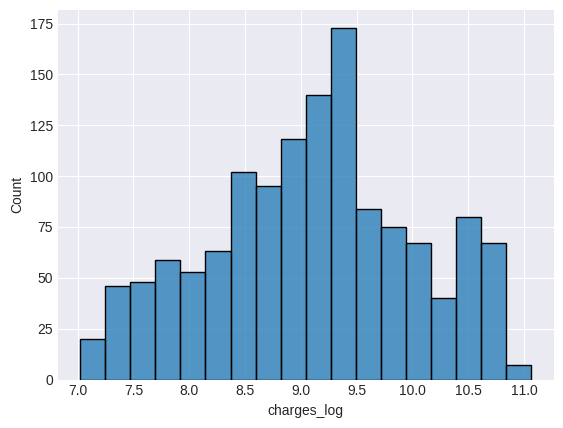

In [ ]:
#data cleaning after eda (1)
#log transform buat mengurangi skewness column charges
df['charges_log'] = np.log(df['charges'])
sns.histplot(df['charges_log'])
df

# **EDA**

# Univariate Analysis

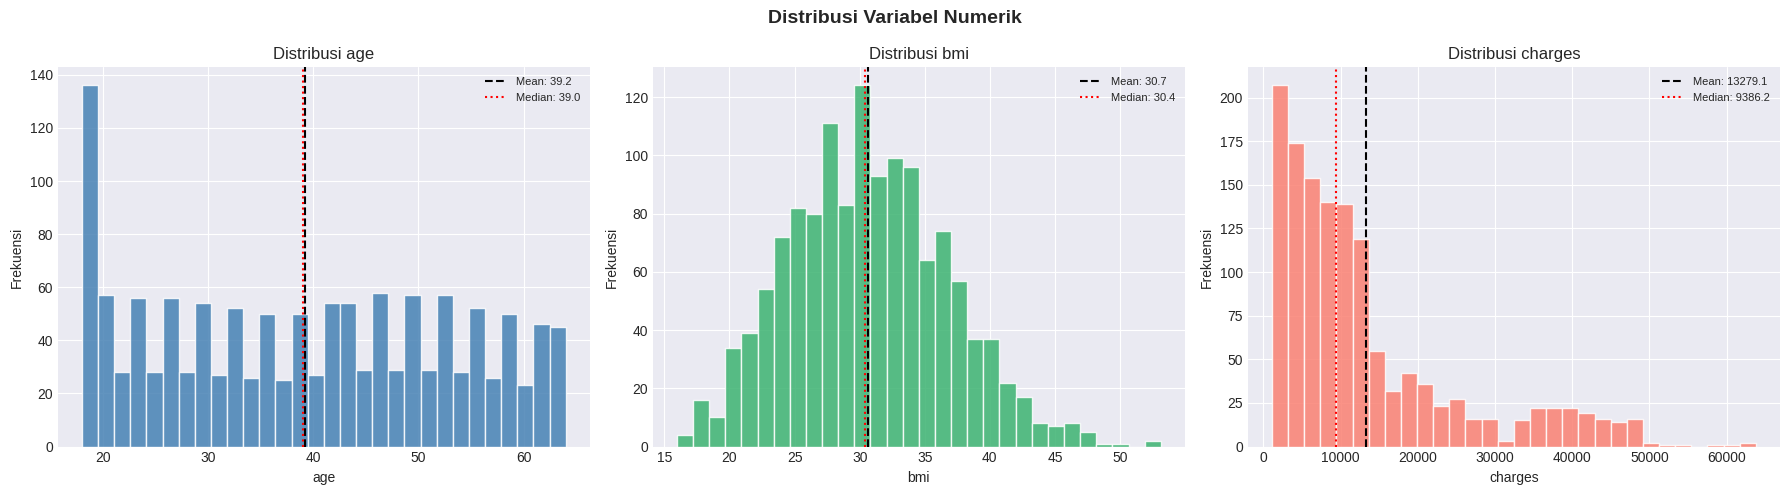

In [ ]:
# Distribusi variabel numerik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

num_cols = ['age', 'bmi', 'charges']
colors   = ['steelblue', 'mediumseagreen', 'salmon']

for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='red', linestyle=':', linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# **Interpretasi**
1. Age: Usia nasabah tersebar merata dari 18 sampai 64 tahun.
  Artinya dataset ini mencakup berbagai kelompok usia secara
  seimbang, dari yang muda sampai yang sudah tua.

2. BMI: Sebagian besar nasabah punya BMI di kisaran 25–35,
  dengan rata-rata sekitar 30. Ini menunjukkan kebanyakan
  nasabah masuk kategori overweight, yang bisa jadi salah
  satu faktor risiko kesehatan.

3. Charges: Sebagian besar nasabah membayar biaya yang
  relatif rendah, tapi ada segelintir nasabah yang biayanya
  sangat tinggi. Ini wajar karena biaya medis memang tidak
  merata — yang sakit parah atau perokok biasanya jauh lebih
  mahal.


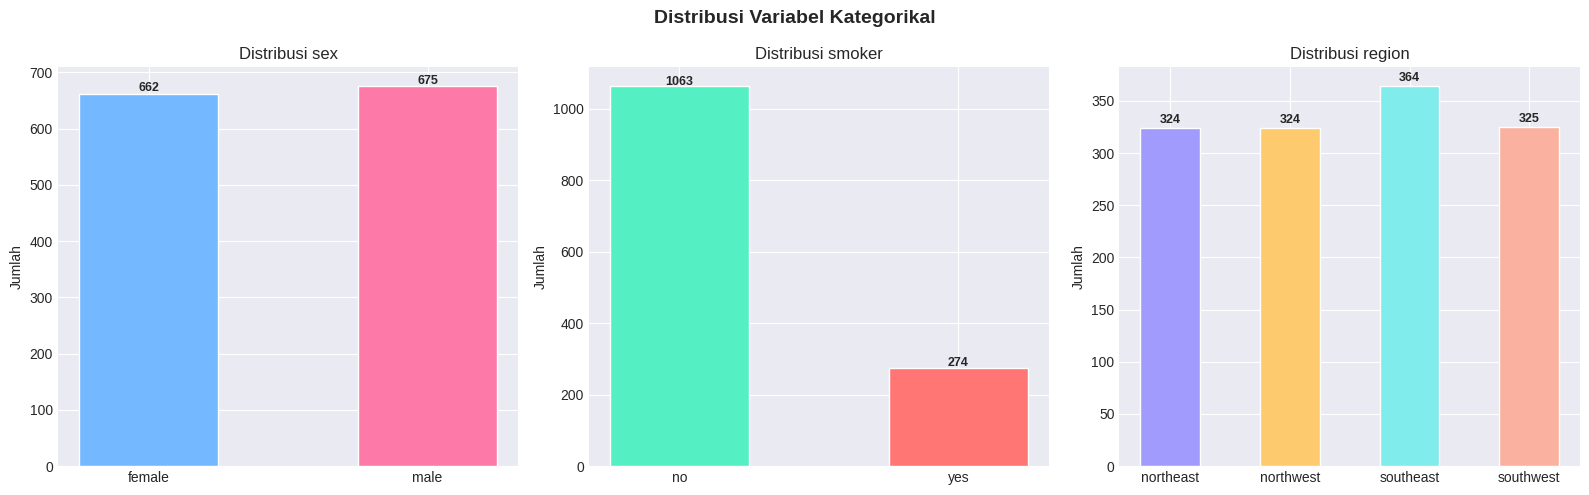

In [ ]:
# Distribusi variabel kategorikal
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')

cat_info = [
    ('sex',    ['female', 'male'],                               ['#74b9ff', '#fd79a8']),
    ('smoker', ['no', 'yes'],                                    ['#55efc4', '#ff7675']),
    ('region', ['northeast','northwest','southeast','southwest'],['#a29bfe','#fdcb6e','#81ecec','#fab1a0']),
]

for ax, (col, order, palette) in zip(axes, cat_info):
    vc = df[col].value_counts().reindex(order)
    bars = ax.bar(vc.index, vc.values, color=palette, edgecolor='white', width=0.5)
    ax.set_title(f'Distribusi {col}')
    ax.set_ylabel('Jumlah')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                str(int(b.get_height())), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# **Interpretasi**
1. Sex: Jumlah nasabah pria dan wanita hampir sama,
  jadi tidak ada ketimpangan gender dalam dataset ini.

2. Smoker: Dari seluruh nasabah, sekitar 80% tidak merokok
  dan 20% perokok. Meski perokok lebih sedikit, nanti akan
  terlihat bahwa mereka punya dampak besar terhadap biaya.

3. Region: Nasabah tersebar di 4 wilayah dengan jumlah yang
  hampir sama. Wilayah southeast sedikit lebih banyak,
  tapi perbedaannya tidak terlalu jauh.

# Bivariate Analysis

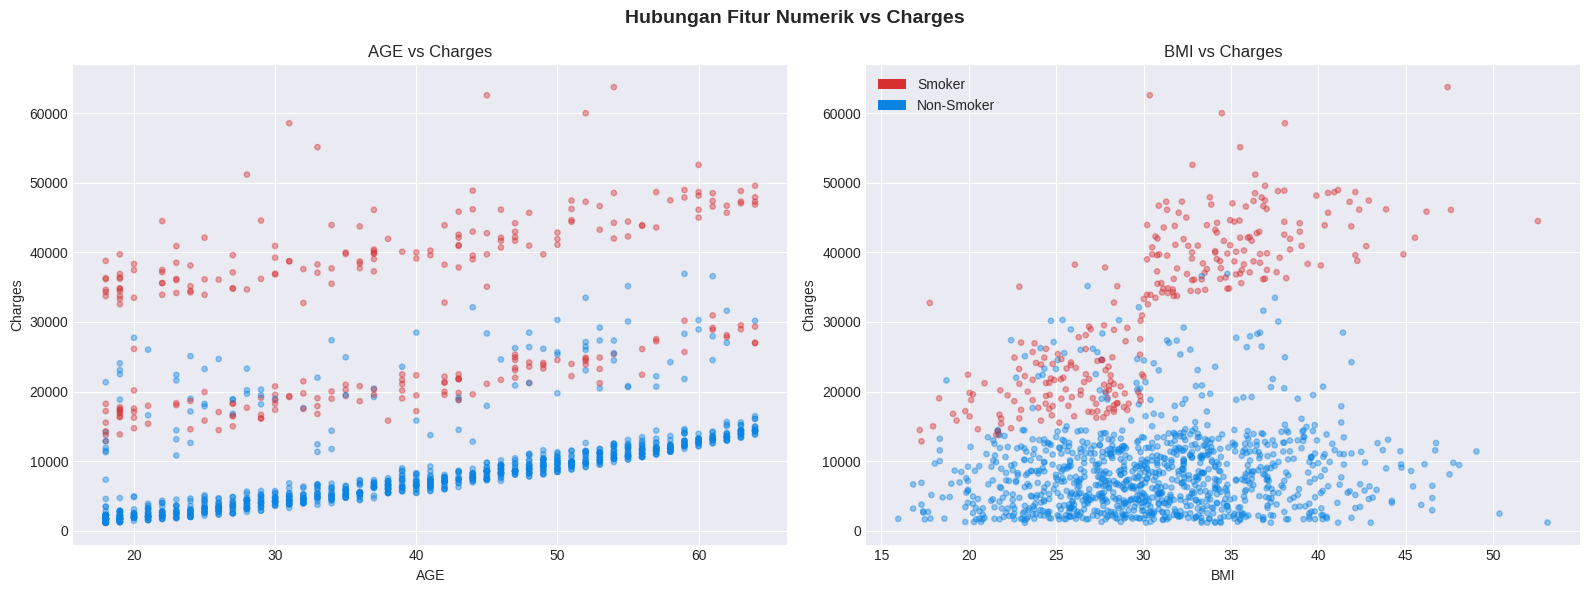

In [ ]:
# Scatter plot: Age & BMI vs Charges
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hubungan Fitur Numerik vs Charges', fontsize=14, fontweight='bold')

colors_smoker = df['smoker'].map({'yes': '#d63031', 'no': '#0984e3'})

for ax, col in zip(axes, ['age', 'bmi']):
    ax.scatter(df[col], df['charges'], c=colors_smoker, alpha=0.4, s=15)
    ax.set_xlabel(col.upper())
    ax.set_ylabel('Charges')
    ax.set_title(f'{col.upper()} vs Charges')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d63031', label='Smoker'),
                   Patch(facecolor='#0984e3', label='Non-Smoker')]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# **Interpretasi**
1. Age vs Charges: Semakin tua usia seseorang, biaya
  asuransinya cenderung naik. Menariknya, kalau dilihat
  dari warna titiknya, perokok (merah) selalu bayar lebih
  mahal dibanding non-perokok (biru) di semua kelompok usia.

2. BMI vs Charges: Nasabah dengan BMI tinggi yang juga
  perokok punya biaya paling tinggi. Tapi yang tidak
  merokok, meskipun BMI-nya tinggi, biayanya tetap jauh
  lebih rendah. Ini menunjukkan merokok lebih berpengaruh
  daripada BMI itu sendiri.

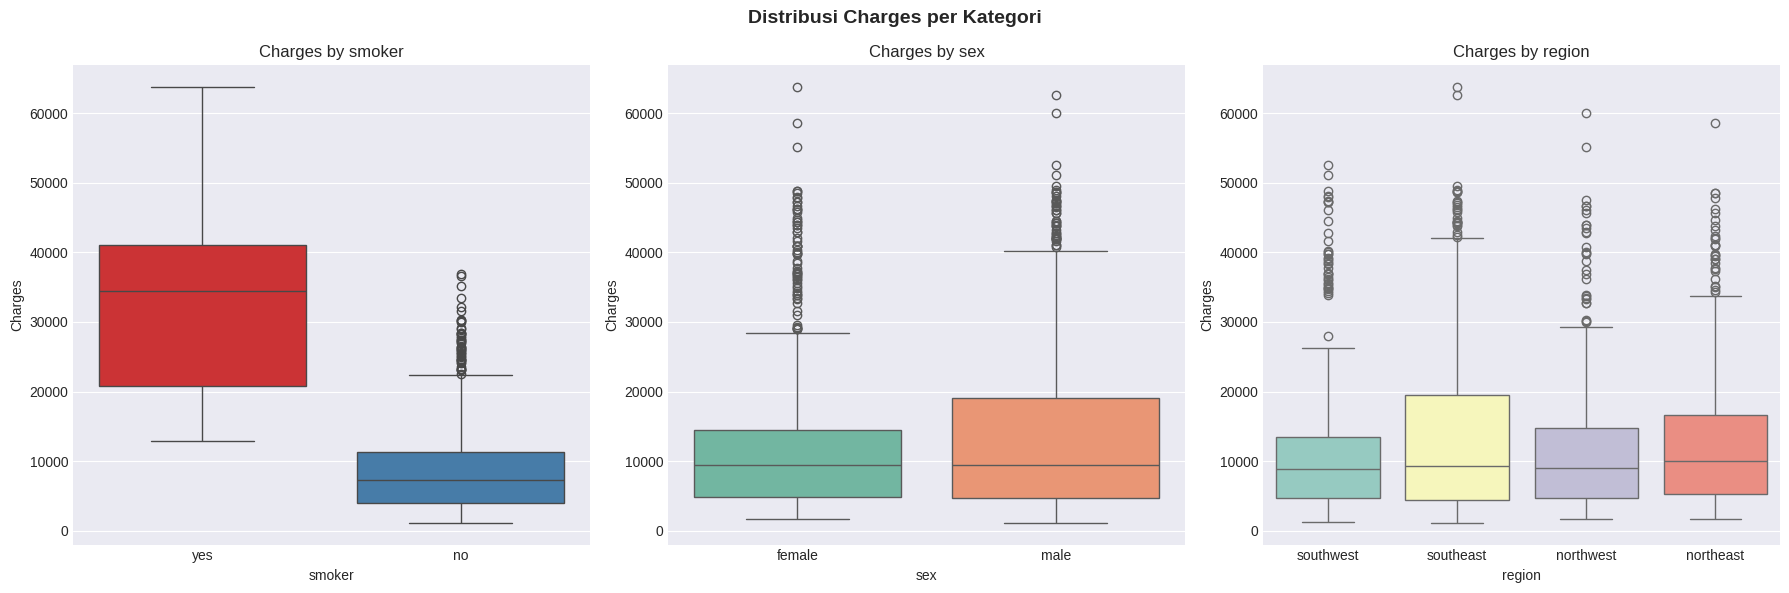

In [ ]:
# Box plot: variabel kategorikal vs charges
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Charges per Kategori', fontsize=14, fontweight='bold')

cat_cols = ['smoker', 'sex', 'region']
palettes = ['Set1', 'Set2', 'Set3']

for ax, col, pal in zip(axes, cat_cols, palettes):
    sns.boxplot(data=df, x=col, y='charges', ax=ax, palette=pal, hue=col, legend=False)
    ax.set_title(f'Charges by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Charges')

plt.tight_layout()
plt.show()

# **Interpretasi**
1. Smoker vs Charges: Ini yang paling mencolok — biaya
  perokok bisa 3x lebih mahal dari non-perokok. Jelas
  banget perbedaannya dari boxplot-nya.

2. Sex vs Charges: Tidak ada perbedaan berarti antara
  pria dan wanita. Biayanya hampir sama.

3. Region vs Charges: Biaya di semua wilayah juga hampir
  sama. Southeast sedikit lebih tinggi, tapi tidak
  signifikan.


# Multivariate Analysis

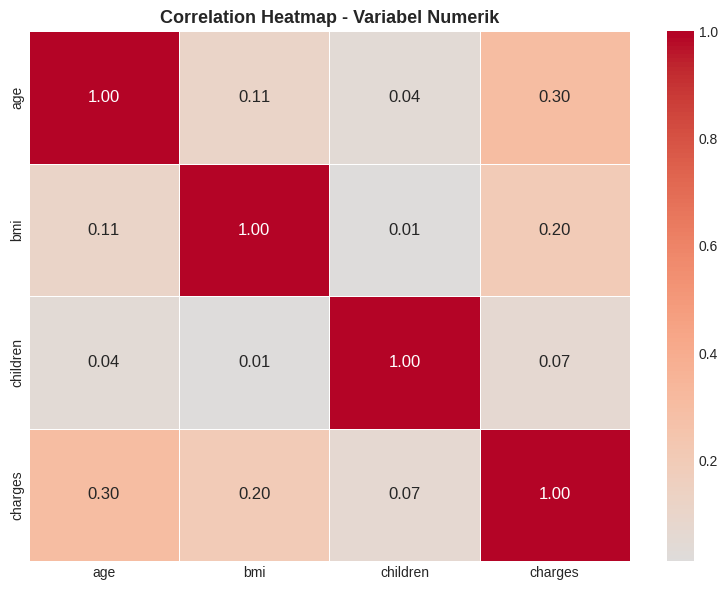

In [ ]:
# Correlation heatmap
num_df = df[['age', 'bmi', 'children', 'charges']]
corr   = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 12})
plt.title('Correlation Heatmap - Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **Interpretasi**
1. Dari semua variabel numerik, age punya korelasi
  tertinggi dengan charges (r = 0.30), artinya usia
  cukup berpengaruh terhadap biaya.

2. BMI punya korelasi lebih kecil (r = 0.20), dan
  children hampir tidak berkorelasi sama sekali (r = 0.07).

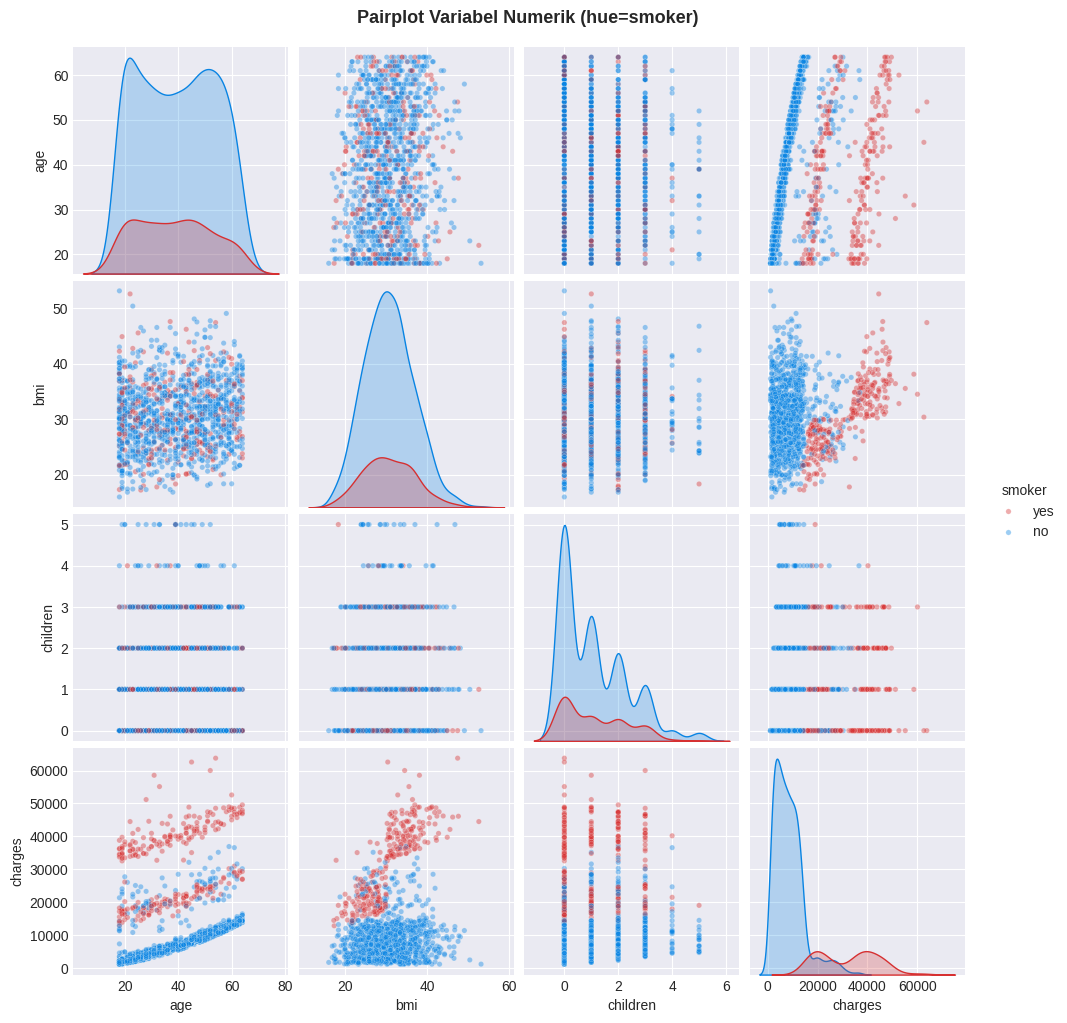

In [ ]:
# Pairplot semua variabel numerik
sns.pairplot(df[['age', 'bmi', 'children', 'charges', 'smoker']],
             hue='smoker', palette={'yes':'#d63031','no':'#0984e3'},
             plot_kws={'alpha':0.4, 's':15})
plt.suptitle('Pairplot Variabel Numerik (hue=smoker)', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()

# **Interpretasi**
Di hampir semua grafik, terlihat jelas dua kelompok
  yang terpisah antara perokok dan non-perokok.
  Perokok selalu ada di posisi charges lebih tinggi.
  Ini membuktikan bahwa status merokok adalah faktor
  paling dominan di dataset ini.

# FEATURE ENGINEERING


#### <center> 'Outlet_Size' Imputation

In [ ]:
# 1. Handling Outliers: Capping BMI

In [ ]:
# Even if data is clean, extreme BMI values can skew linear models.

In [ ]:
# We cap BMI at the 99th percentile to handle extreme outliers.
bmi_upper_limit = df['bmi'].quantile(0.99)
df['bmi'] = np.where(df['bmi'] > bmi_upper_limit, bmi_upper_limit, df['bmi'])
print("BMI capping applied. Head of DataFrame after capping:")
display(df.head())

BMI capping applied. Head of DataFrame after capping:


,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


In [ ]:
# 2. Feature Creation: BMI Category

In [ ]:
# Categorizing BMI helps the model capture non-linear health risks.
def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif 18.5 <= bmi < 25:
        return 'normal'
    elif 25 <= bmi < 30:
        return 'overweight'
    else:
        return 'obese'

df['bmi_category'] = df['bmi'].apply(get_bmi_category)

In [ ]:
# 3. Feature Creation: Interaction Feature (Age * Smoker)

In [ ]:
# Risk increases significantly for older smokers compared to younger ones.

In [ ]:
# We will map 'smoker' first to create this numerical interaction.
df['smoker_numeric'] = df['smoker'].map({'yes': 1, 'no': 0})
df['age_smoker_interaction'] = df['age'] * df['smoker_numeric']

one hot encoding for 'region' and 'bmi_category'

In [ ]:
# 4. Feature Encoding

In [ ]:
# We use drop_first=True to avoid the Dummy Variable Trap (Multicollinearity).
df = pd.get_dummies(df, columns=['region', 'bmi_category'], drop_first=True)

In [ ]:
# Binary Encoding for 'sex' and 'smoker'

In [ ]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker_numeric'] # already mapped above
df.drop('smoker_numeric', axis=1, inplace=True)



# MODEL BUILDING

split data

In [ ]:
# Hapus baik target asli ('charges') maupun turunannya ('charges_log') dari fitur X
X = df.drop(["charges", "charges_log"], axis=1)
y = df["charges"]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Fitur yang digunakan:", X.columns.tolist())

Fitur yang digunakan: ['age', 'sex', 'bmi', 'children', 'smoker', 'age_smoker_interaction', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_obese', 'bmi_category_overweight', 'bmi_category_underweight']


##Train model liner regression

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

prediksi

In [ ]:
y_pred = model.predict(X_val)

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_regressor = RandomForestRegressor(random_state=0)

param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [6, 8, 10],       # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

grid_search_rf = GridSearchCV(rf_regressor, param_grid_rf, cv=5,scoring='r2')

grid_search_rf.fit(X_train, y_train)

print("Best params:", grid_search_rf.best_params_)

Best params: {'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
rf_regressor_tuned = RandomForestRegressor(random_state=0, max_depth=6, min_samples_leaf=4, min_samples_split=10, n_estimators=100)

rf_regressor_tuned.fit(X_train, y_train)

y_pred_rf = rf_regressor_tuned.predict(X_val)


## MODEL EVALUATION

##Linear Regression

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4329.2248027872765
RMSE: 6009.556061818022
R2 Score: 0.8034635523535364


##Random Forest

In [ ]:
mae_rf = mean_absolute_error(y_val, y_pred_rf)
mse_rf = mean_squared_error(y_val, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_val, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 2422.8763976378236
RMSE: 4269.042314345648
R2 Score: 0.9008211109833226


visualisasi

##Linear Regression

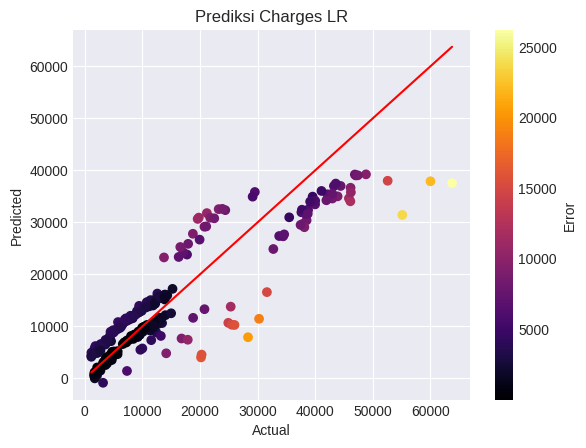

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")

error = np.abs(y_val - y_pred)

plt.scatter(y_val, y_pred, c=error, cmap='inferno')
plt.colorbar(label="Error")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediksi Charges LR")

plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red')
plt.show()

##Random Forest

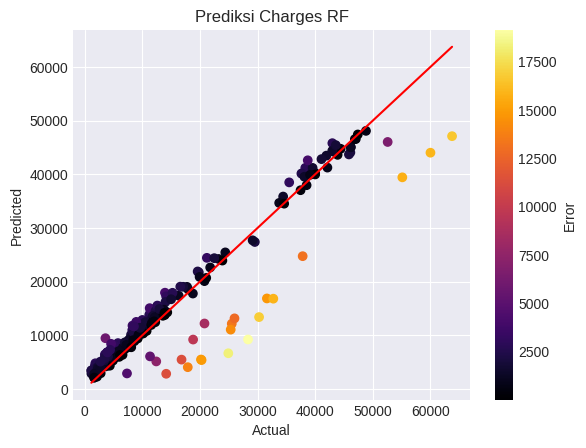

In [ ]:
error = np.abs(y_val - y_pred_rf)

plt.scatter(y_val, y_pred_rf, c=error, cmap='inferno')
plt.colorbar(label="Error")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediksi Charges RF")

plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red')
plt.show()

Berdasarkan hasil evaluasi, model Random Forest memiliki performa yang lebih baik dibandingkan Linear Regression. Hal ini terlihat dari nilai MAE dan RMSE yang lebih kecil, serta R² yang lebih tinggi. Dengan demikian, Random Forest lebih akurat dalam memprediksi nilai charges